# InfyChain Data Science Internship
## Task 3: Exploratory Data Analysis (EDA)
**Dataset:** Netflix Dataset
**Objective:** Identify trends and patterns

### 1. Import Libraries & Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Download via Kaggle API:
#   kaggle datasets download -d shivamb/netflix-shows --unzip
# File is usually named "netflix_titles.csv"

df = pd.read_csv("netflix_titles.csv")

print("Shape:", df.shape)
df.head()

Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### 2. Summary Statistics

In [3]:
print("--- Summary Statistics ---")
df.describe(include="all")

--- Summary Statistics ---


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [4]:
print("Missing values:")
df.isnull().sum()

Missing values:


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
# Basic cleaning for EDA purposes
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df.dropna(subset=["date_added"], inplace=True)

# Extract year_added and month_added from date_added
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce")
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

print("Content type counts:")
print(df["type"].value_counts())

Content type counts:
type
Movie      6131
TV Show    2666
Name: count, dtype: int64


In [6]:
print("Top 10 countries producing content:")
print(df["country"].value_counts().head(10))

Top 10 countries producing content:
country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [7]:
print("Top 10 ratings:")
print(df["rating"].value_counts().head(10))

Top 10 ratings:
rating
TV-MA    3209
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64


### 3. Correlation Analysis

In [8]:
# Netflix data is mostly categorical, so correlation is limited.
# We'll analyze release_year range instead.
print("Release year range:", df["release_year"].min(), "-", df["release_year"].max())

Release year range: 1925 - 2021


### 4. Trend Identification

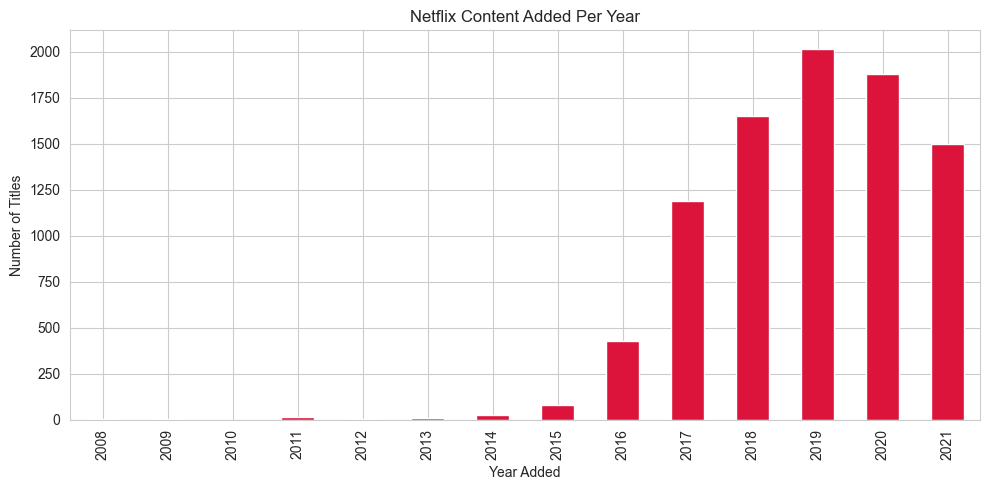

In [9]:
sns.set_style("whitegrid")

# Trend 1: Content added per year
plt.figure(figsize=(10, 5))
df["year_added"].value_counts().sort_index().plot(kind="bar", color="crimson")
plt.title("Netflix Content Added Per Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.savefig("content_added_per_year.png")
plt.show()

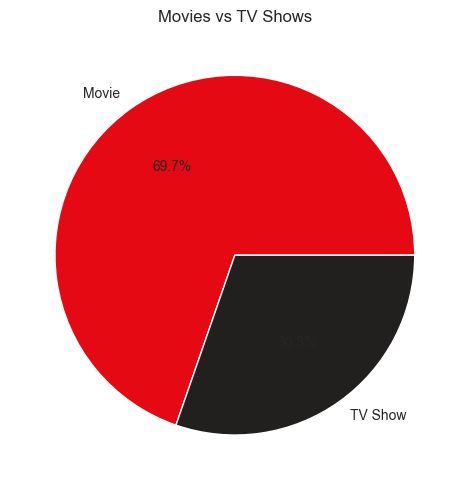

In [10]:
# Trend 2: Movies vs TV Shows
plt.figure(figsize=(6, 5))
df["type"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["#E50914", "#221f1f"])
plt.title("Movies vs TV Shows")
plt.ylabel("")
plt.tight_layout()
plt.savefig("movies_vs_tv_shows.png")
plt.show()

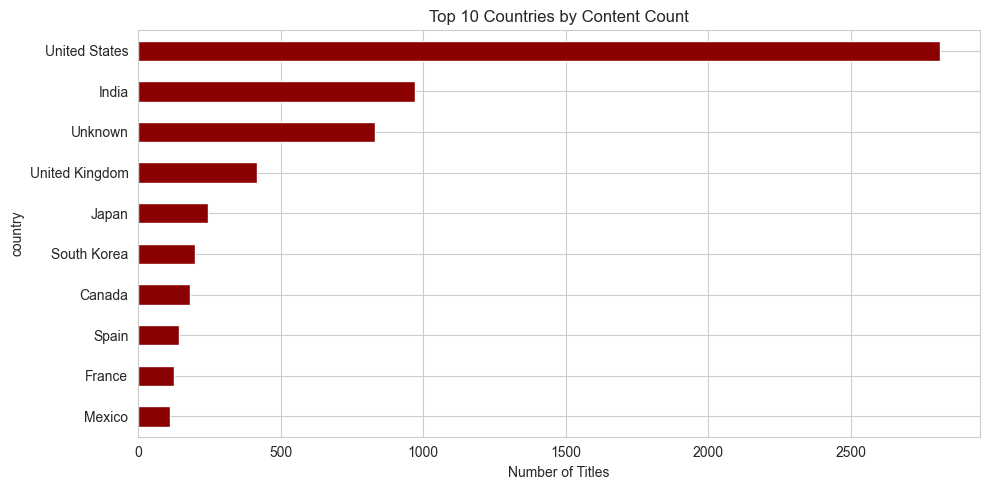

In [11]:
# Trend 3: Top 10 content-producing countries
plt.figure(figsize=(10, 5))
df["country"].value_counts().head(10).plot(kind="barh", color="darkred")
plt.title("Top 10 Countries by Content Count")
plt.xlabel("Number of Titles")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top_10_countries.png")
plt.show()

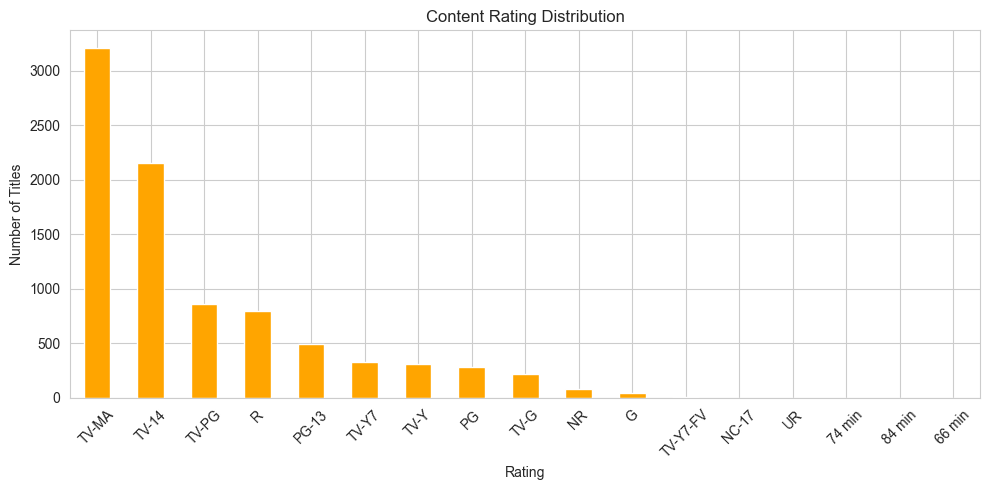

In [12]:
# Trend 4: Content rating distribution
plt.figure(figsize=(10, 5))
df["rating"].value_counts().plot(kind="bar", color="orange")
plt.title("Content Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("rating_distribution.png")
plt.show()

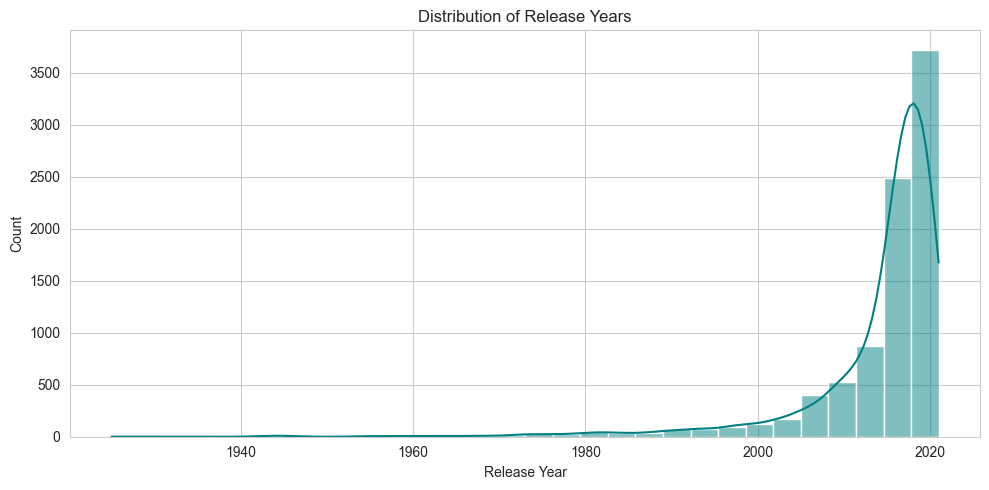

In [13]:
# Trend 5: Release year distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["release_year"], bins=30, kde=True, color="teal")
plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.tight_layout()
plt.savefig("release_year_distribution.png")
plt.show()

### 5. Key Insights Summary

In [14]:
insights = f"""
Netflix Dataset - Key Insights
================================
Total titles analyzed: {df.shape[0]}
Movies: {df[df['type']=='Movie'].shape[0]}
TV Shows: {df[df['type']=='TV Show'].shape[0]}
Top content-producing country: {df['country'].value_counts().index[0]}
Most common rating: {df['rating'].value_counts().index[0]}
Peak year for content added: {df['year_added'].value_counts().idxmax()}
Oldest title release year: {df['release_year'].min()}
Newest title release year: {df['release_year'].max()}
"""

print(insights)

with open("netflix_insights_summary.txt", "w") as f:
    f.write(insights)

print("All charts and insights summary saved to project folder.")


Netflix Dataset - Key Insights
Total titles analyzed: 8797
Movies: 6131
TV Shows: 2666
Top content-producing country: United States
Most common rating: TV-MA
Peak year for content added: 2019
Oldest title release year: 1925
Newest title release year: 2021

All charts and insights summary saved to project folder.
